# Tunisian ASR — Text Preprocessing (`01_text_preprocessing`)

**Standards implemented:**
| Standard | Year | Key contribution to this pipeline |
|----------|------|-----------------------------------|
| CODA-TUN | Zribi et al., 2014 | Base convention: gaf=ق, neg circumclitic, long vowels |
| COTA 2.0 | Boujelbane et al., 2022 | Agglutination rules, Taa-Marbuta/Ha confusion fixes |
| CODA* | Habash et al. / CAMeL, 2018–2023 | Simplified Hamza, Waw-of-Plurality وا, unified framework |
| NOTA | Turki et al., arXiv:2402.12940, 2024 | TUN user-friendliness pass; /y/→ي; /ə/→و; glottal-stop rules |

**Pipeline:** `raw transcript → cleaning → code-switch → NOTA → quality gate → save`

### Road-map
| § | Section | Output column |
|---|---------|---------------|
| 1 | Environment & config | — |
| 2 | Load data | — |
| 3 | Redundancy check | — |
| 4 | Basic cleaning | `transcript_clean` |
| 5 | Code-switch handling | `transcript_cs` |
| 6 | NOTA normalisation | `transcript_nota` |
| 7 | Deep analysis | figures + stats |
| 8 | Quality gate | filtered DataFrames |
| 9 | Save outputs | parquet + drop log |
| 10 | Summary | report |


## 1 · Environment & Config

In [3]:
%load_ext autoreload
%autoreload 2


In [4]:
import sys, json, re, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

PROJECT_ROOT = str(Path.cwd().parent.resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# src is a proper package — use src.* imports throughout
from src.utils               import (load_config, ensure_dir, print_dict,
                                     print_section, extract_words_from_pattern)
from src.audit_text          import (get_char_vocab, get_word_vocab,
                                     categorize_vocab, classify_char,
                                     CATEGORY_COLORS, visualize_characters)
from src.cleaning            import (clean_transcript, clean_dataframe,
                                     load_transcript_corrections)
from src.nota_normalizer     import NOTANormalizer
from src.code_switch_handler import CodeSwitchHandler

try:
    from rapidfuzz import fuzz
    _FUZZ_OK = True
except ImportError:
    _FUZZ_OK = False
    print("⚠ rapidfuzz not installed — similarity check will be skipped")

print("✓ imports OK")


✓ imports OK


In [5]:
paths  = load_config(f"{PROJECT_ROOT}/configs/paths.yaml")
pp_cfg = load_config(f"{PROJECT_ROOT}/configs/preprocessing_config.yaml")

REPORTS_PATH  = str(Path(PROJECT_ROOT) / paths["outputs"]["reports"])
FIGURES_PATH  = str(Path(PROJECT_ROOT) / paths["outputs"]["figures"])
TEXT_OUT_PATH = str(Path(PROJECT_ROOT) / paths["interim"]["text_clean"])
LEXICONS_DIR  = str(Path(PROJECT_ROOT) / pp_cfg["nota"]["lexicons_dir"])
CORRECTIONS_PATH = str(Path(PROJECT_ROOT) / paths["data"]["transcript_corrections"])

ensure_dir(TEXT_OUT_PATH)
ensure_dir(FIGURES_PATH)

KEEP_DIGITS        = pp_cfg["cleaning"]["keep_digits"]
MIN_TRANSCRIPT_LEN = pp_cfg["cleaning"]["min_transcript_length"]
CS_POLICY          = pp_cfg["code_switch"]["policy"]
N_EXAMPLES         = pp_cfg["display"]["n_examples"]
MIN_SIM_SCORE      = pp_cfg["similarity"]["min_similarity_score"]

# Layer flags for NOTANormalizer (from config)
NOTA_LAYER_FLAGS = {k: pp_cfg["nota"][k] for k in pp_cfg["nota"]
                    if k.startswith("apply_")}

# Dataset-specific transcript corrections loaded from TSV — not hardcoded
corrections = load_transcript_corrections(CORRECTIONS_PATH)

print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print(f"LEXICONS_DIR      : {LEXICONS_DIR}")
print(f"TEXT_OUT_PATH     : {TEXT_OUT_PATH}")
print(f"Corrections loaded: {len(corrections)} rules from {CORRECTIONS_PATH}")
print(f"keep_digits={KEEP_DIGITS}  cs_policy={CS_POLICY}  min_len={MIN_TRANSCRIPT_LEN}")
print(f"NOTA layers : {NOTA_LAYER_FLAGS}")


PROJECT_ROOT      : C:\Users\MSI\Desktop\ASR\asr_tn_pielines
LEXICONS_DIR      : C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\lexicons
TEXT_OUT_PATH     : C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\text_clean
Corrections loaded: 12 rules from C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\lexicons\transcript_corrections.tsv
keep_digits=True  cs_policy=arabize  min_len=2
NOTA layers : {'apply_alef_maqsura': False, 'apply_taa_marbuta': False, 'apply_waw_plurality': False, 'apply_hamza_drop': True, 'apply_negation_split': True, 'apply_variant_map': True, 'apply_overrides': True}


## 2 · Load Data

In [7]:
df_train = pd.read_parquet(f"{REPORTS_PATH}/df_train_segments.parquet")
df_test  = pd.read_parquet(f"{REPORTS_PATH}/df_test_segments.parquet")

print(f"df_train: {df_train.shape[0]:,} rows × {df_train.shape[1]} cols")
print(f"df_test : {df_test.shape[0]:,} rows × {df_test.shape[1]} cols")
print("Columns:", df_train.columns.tolist())
df_train[["audio_id","seg_start","seg_end","transcript","transcript_raw"]].head(3)


df_train: 76,115 rows × 11 cols
df_test : 1,013 rows × 11 cols
Columns: ['audio_id', 'seg_start', 'seg_end', 'transcript', 'transcript_raw', 'char_count', 'word_count', 'has_latin', 'has_diacritics', 'seg_duration', 'speech_rate']


,audio_id,seg_start,seg_end,transcript,transcript_raw
0,amenyKH_0000001_0000020_1_20_0,0.0,14.113000,أسبقية قبل أنا ما وصلت خممت فيه كيما باش نحكيو...,أسبقية قبل أنا ما وصلت خممت فيه كيما باش نحكيو...
1,amenyKH_0000001_chunk_0000001_001_chunk_1_0,0.0,3.496625,و الصلاة و السلام على رسول الله,و الصلاة و السلام على رسول الله
2,amenyKH_0000001_chunk_0000002_001_chunk_2_0,0.0,4.328063,و على آله وصحابته و من والاه,و على آله وصحابته و من والاه


## 3 · Redundancy Check: `transcript` vs `transcript_raw`

Both columns originate from the same annotation. We confirm `transcript` is the
correct working reference and retain `transcript_raw` only for provenance.


In [9]:
if _FUZZ_OK:
    def _sim_score(df, n=5000):
        idx = df.sample(min(n, len(df)), random_state=42).index
        return float(np.mean([
            fuzz.ratio(str(df.at[i,"transcript"]), str(df.at[i,"transcript_raw"]))
            for i in idx
        ]))
    train_sim = _sim_score(df_train)
    test_sim  = _sim_score(df_test)
    print(f"Similarity  train: {train_sim:.2f}%  test: {test_sim:.2f}%")
    if train_sim >= MIN_SIM_SCORE:
        print(f"✓ ≥{MIN_SIM_SCORE}% → 'transcript' is the reference column.")
    else:
        print(f"⚠ <{MIN_SIM_SCORE}% — inspect differences before proceeding.")
else:
    print("Skipped (rapidfuzz not available)")


Similarity  train: 99.51%  test: 99.92%
✓ ≥80% → 'transcript' is the reference column.


In [10]:
diff_mask = df_train["transcript"] != df_train["transcript_raw"]
print(f"Rows where transcript ≠ transcript_raw: {diff_mask.sum():,} ({diff_mask.mean()*100:.1f}%)")
display(df_train[diff_mask][["transcript", "transcript_raw"]].head(N_EXAMPLES).style.set_properties(**{
    'text-align': 'right', 'direction': 'rtl', 'font-size': '12px'
}).hide())


Rows where transcript ≠ transcript_raw: 9,113 (12.0%)


transcript,transcript_raw
تقول إلي يحب فيسع المجلس تأسيسي يحب يشد رئيس زادا نفس الشي معناتها المجلس التأسيسي موش جاي يحب يحكم,تقول إلي يحب فيسع المجلس تأسيسي يحب يشد رئيس زادة نفس الشي معناتها المجلس التأسيسي موش جاي يحب يحكم
لكن لا رجل الاستثمار ولا أيه وزير قادر باش يدخل على اصلاحات جذرية و هذا في البلاد,لكن لا رجل الاستثمار ولا أي وزير قادر باش يدخل على اصلاحات جذرية و هذا في البلاد
آه أنا المختص صاحب الاختصاص موش واحد تجي تحطو في وزارة الفلاحة وما يعرفش الفلاحة ولاخر تحطو,آه أنا المختص صاحب الاختصاص موش واحد تجي تحطو في وزارة الفلاحة وما يعرفش الفلاحة و الاخر تحطو
أيه أيه نعم أيه نعم,أيه أي نعم أي نعم
موش أيه واحد ينجم ينجح فيه,موش أي واحد ينجم ينجح فيه
هل أنو ثمة نفسية زادا ربما,هل أنو ثمة نفسية زادة ربما
هل أنو زادا الإرادة والعزيمة عندها أهمية في خيار الإقلاع على التدخين,هل أنو زادة الإرادة والعزيمة عندها أهمية في خيار الإقلاع على التدخين
بلا نيكوتين فوالا ما نجمتش زادا ما نعرفش أنا,بلا نيكوتين فوالا ما نجمتش زادة ما نعرفش أنا
عندي إقتراح نقترح إلي الدولة زادا تخمم فيها مليح يعملوا ديه سنتر موش لي أنا بركة يعني الناس الكل إلي تحب,عندي إقتراح نقترح إلي الدولة زادة تخمم فيها مليح يعملوا ديه سنتر موش لي أنا بركة يعني الناس الكل إلي تحب
باهي أنا سي محمد أنا مذابية باش المدخنين زادا إلي خذاو القرار هذا كيما سهام ما نجمتش تنجح فيه,باهي أنا سي محمد أنا مذابية باش المدخنين زادة إلي خذاو القرار هذا كيما سهام ما نجمتش تنجح فيه


## 4 · Basic Cleaning (`cleaning.py`)

| Step | Transformation | Standard |
|------|---------------|----------|
| 1 | Remove URLs, hashtags, @mentions | noise |
| 2 | Unicode NFC normalisation | NOTA §1 |
| 3 | Unify Alef variants أإٱ → ا  | NOTA §2 / CODA* |
| 4 | Strip all diacritics (harakat, shadda, tanwin) | NOTA §3 |
| 5 | Remove punctuation (Arabic + Latin) | preprocessing |
| 6 | Digit handling (Arabic-Indic → Western, or remove) | configurable |
| 7 | Universal char substitutions (dialect letters, French accents, Unicode artifacts) | systematic |
| 8 | Dataset-specific transcript corrections (from `transcript_corrections.tsv`) | EDA-driven |
| 9 | Collapse whitespace | normalise |

Result stored in `transcript_clean`; original `transcript` is never overwritten.  
`clean_dataframe` returns a **copy** — the input DataFrame is never mutated.


In [12]:
df_train = clean_dataframe(df_train, col="transcript",
                          keep_digits=KEEP_DIGITS, corrections=corrections)
df_test  = clean_dataframe(df_test,  col="transcript",
                          keep_digits=KEEP_DIGITS, corrections=corrections)

n_changed_train = (df_train["transcript"] != df_train["transcript_clean"]).sum()
n_changed_test  = (df_test["transcript"]  != df_test["transcript_clean"]).sum()
print(f"Segments modified by cleaning (train): {n_changed_train:6,} / {len(df_train):6,} ({n_changed_train/len(df_train)*100:.1f}%)")
print(f"Segments modified by cleaning (test) : {n_changed_test:6,} / {len(df_test):6,} ({n_changed_test/len(df_test)*100:.1f}%)")


Segments modified by cleaning (train): 18,062 / 76,115 (23.7%)
Segments modified by cleaning (test) :    443 /  1,013 (43.7%)


In [13]:
# Before/after diff sample
mask    = df_train["transcript"] != df_train["transcript_clean"]
df_diff = df_train[mask].head(N_EXAMPLES)
display(df_diff[["transcript", "transcript_clean"]].style.set_properties(**{
    'text-align': 'right', 'direction': 'rtl', 'font-size': '12px'
}).hide())


transcript,transcript_clean
أسبقية قبل أنا ما وصلت خممت فيه كيما باش نحكيو من بعد إلا ما أنا كإنطريبرنور كباعث مشروع صارولي برشا مشاكل فالجستين و صارولي مشاكل مع لعباد لي كانت موفرتلي اللوجسيل ولا اللوجسيل أوف لنيه ولا لوجسيل بيراتي,اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو من بعد الا ما انا كانطريبرنور كباعث مشروع صارولي برشا مشاكل فالجستين و صارولي مشاكل مع لعباد لي كانت موفرتلي اللوجسيل ولا اللوجسيل اوف لنيه ولا لوجسيل بيراتي
ربنا لا تزغ قلوبنا بعد إذ هديتنا,ربنا لا تزغ قلوبنا بعد اذ هديتنا
إنك أنت الوهاب,انك انت الوهاب
إنك إنك جامع الناس اليوم لا ريب فيه,انك انك جامع الناس اليوم لا ريب فيه
إنا الله لا يخلف الميعاد,انا الله لا يخلف الميعاد
وأخلص نيتو لله,واخلص نيتو لله
قالوا لهم أحنا العدد متاعنا محدود,قالوا لهم احنا العدد متاعنا محدود
أكثر قبايل العرب ما زالوا ما دخلوش الإسلام,اكثر قبايل العرب ما زالوا ما دخلوش الاسلام
تحزبوا أحزاب أحزاب أحزاب,تحزبوا احزاب احزاب احزاب
وسمع الرسول الأكرم صلى الله عليه وسلم,وسمع الرسول الاكرم صلى الله عليه وسلم


### 4.1 · Diacritic removal impact

Confirm that diacritics are fully removed and measure how many tokens
were affected.


In [15]:
_DIAC = re.compile(r"[\u064B-\u065F\u0670]")
still_train = df_train["transcript_clean"].str.contains(_DIAC.pattern, regex=True).sum()
still_test  = df_test["transcript_clean"].str.contains(_DIAC.pattern, regex=True).sum()

print(f"Segments with diacritics after cleaning (train): {still_train:,}  {'✓ none remain' if still_train==0 else '⚠ inspect below'}")
print(f"Segments with diacritics after cleaning (test) : {still_test:,}  {'✓ none remain' if still_test==0 else '⚠ inspect below'}")


Segments with diacritics after cleaning (train): 0  ✓ none remain
Segments with diacritics after cleaning (test) : 0  ✓ none remain


### 4.2 · Empty transcript detection

Segments that become empty after cleaning are noise (silence, music,
untranscribed content). We log them but do not drop them yet — the formal
quality gate in section 8 handles the filtering.


In [17]:
empty_train = (df_train["transcript_clean"].str.strip().str.len() == 0)
empty_test  = (df_test["transcript_clean"].str.strip().str.len() == 0)

print(f"Empty transcripts (train): {empty_train.sum():2,} ({empty_train.mean()*100:.2f}%)")
print(f"Empty transcripts (test) : {empty_test.sum():2,} ({empty_test.mean()*100:.2f}%)")

if empty_train.sum() > 0:
    print("\nSample of empty segments (train):")
    display(df_train[empty_train][["audio_id","seg_start","seg_end","transcript"]].head(5))


Empty transcripts (train):  0 (0.00%)
Empty transcripts (test) :  0 (0.00%)


### 4.3 · Transcript corrections preview

Dataset-specific patches loaded from `transcript_corrections.tsv`.  
These are EDA-discovered garbled strings, now auditable without touching Python.


In [19]:
print(f"Active correction rules ({len(corrections)} total):")
df_corr = pd.DataFrame(corrections, columns=["pattern_bad", "replacement"])
df_corr["replacement"] = df_corr["replacement"].apply(lambda x: "(remove)" if x == "" else repr(x))
df_corr["pattern_bad"] = df_corr["pattern_bad"].apply(repr)
display(
    df_corr.head(5).style
    .set_properties(**{
        "text-align": "right",
        "direction": "rtl",
        "font-size": "12px"
    }).hide()
)


Active correction rules (12 total):


pattern_bad,replacement
'و ہ','وه'
'اLي','ايلي'
'اتs',(remove)
'ايm v','ايم قانا'
'الفرحةd','الفرحة'


## 5 · Code-Switch Handling (`code_switch_handler.py`)

TUN code-switching follows a three-tier model per NOTA §6:

| Tier | Example | Action |
|------|---------|--------|
| Arabized loanword (already Arabic script) | بوسطة | no action needed |
| Latin-form integrated loanword | `busta`, `laptop` | Arabize via lookup table |
| Genuine code-switch | `ça va`, `super` | configurable policy |

**Active policy:** `arabize` — replace if in table, else keep (The transliteration is conducted with **GPT-5 model**).  
Non-NOTA phoneme mapping: /g/→ق, /v/→ف, /p/→ب, /y/→ي, /ə/→و


In [21]:
cs_handler = CodeSwitchHandler(
    lexicons_dir=LEXICONS_DIR,
    policy=CS_POLICY,
    case_insensitive=True,
)
print(f"Loanword table entries: {len(cs_handler.loanword_table):,}")
print(f"Policy                : {cs_handler.policy}")

print("-" * 5, "examples", "-" * 5)
for k, j in list(cs_handler.loanword_table.items())[:N_EXAMPLES]:
    print(f"{k:<15} {j:<15}")


Loanword table entries: 4,398
Policy                : arabize
----- examples -----
a               ا              
ability         ابيليتي        
abonnement      ابونمون        
abordes         ابورد          
about           اباوت          
absences        ابسونس         
absolument      ابسولومون      
absurd          ابسورد         
abuse           ابيوز          
academique      اكاديمي        


In [22]:
df_train["transcript_cs"] = cs_handler.process_series(df_train["transcript_clean"])
df_test["transcript_cs"]  = cs_handler.process_series(df_test["transcript_clean"])

n_cs_train = (df_train["transcript_clean"] != df_train["transcript_cs"]).sum()
n_cs_test  = (df_test["transcript_clean"]  != df_test["transcript_cs"]).sum()
print(f"Segments modified by code-switch handling (train): {n_cs_train:6,} ({n_cs_train/len(df_train)*100:.2f}%)")
print(f"Segments modified by code-switch handling (test) : {n_cs_test:6,} ({n_cs_test/len(df_test)*100:.2f}%)")


Segments modified by code-switch handling (train):  4,822 (6.34%)
Segments modified by code-switch handling (test) :    315 (31.10%)


In [23]:
# Discover Latin words not yet in the lookup table — add to loanword_arabization.tsv
unknown_train = cs_handler.get_unknown_latin_words(df_train["transcript_clean"].dropna().tolist(), top_k=N_EXAMPLES)
unknown_test  = cs_handler.get_unknown_latin_words(df_test["transcript_clean"].dropna().tolist(),  top_k=1000)

if unknown_train:
    print(f"Top {N_EXAMPLES} unknown Latin words (candidates for loanword_arabization.tsv):")
    print(f"{'Count':>7}  Word"); print("-"*25)
    for word, cnt in unknown_train: print(f"  {cnt:>5}  {word}")
else:
    print("✓ none remain (train)")

if unknown_test:
    print(f"Top {N_EXAMPLES} unknown Latin words (test):")
    print(f"{'Count':>7}  Word"); print("-"*25)
    for word, cnt in unknown_test[:N_EXAMPLES]: print(f"  {cnt:>5}  {word}")
else:
    print("✓ none remain (test)")


✓ none remain (train)
✓ none remain (test)


In [24]:
# detect_code_switches now returns is_french_stopword per word
latin_mask = df_train["transcript_clean"].str.contains(r"[A-Za-z]", regex=True)
latin_rows = df_train[latin_mask]

if len(latin_rows) > 5:
    sample_text = str(latin_rows.iloc[5]["transcript_clean"])
    detections  = cs_handler.detect_code_switches(sample_text)
    print(f"Original Sample: {sample_text}")
    print(f"Sample After CS: {cs_handler.process(sample_text)}\n")
    if detections:
        print(f"  {'Word':<20} {'In table':<12} {'FR stopword':<14} {'Arabic form':<25}")
        print("  " + "-"*65)
        for d in detections:
            print(f"  {d['word']:<20} {str(d['in_table']):<12} {str(d['is_french_stopword']):<14}   {d['arabic_form']:<25}")
    else:
        print("  (no Latin words detected)")


Original Sample: donc ما زلنا باش نسمعوا ارائكم انتوما عال واحد وسبعين مية وثلتطاشن الف
Sample After CS: دونك ما زلنا باش نسمعوا ارائكم انتوما عال واحد وسبعين مية وثلتطاشن الف

  Word                 In table     FR stopword    Arabic form              
  -----------------------------------------------------------------
  donc                 True         True             دونك                     



========== Train vs Test Code-Switch Summary ==========
            Metric  Train  Test  Train (%)   Test (%)
    Total segments  76115  1013 100.000000 100.000000
  With Latin (raw)   4822   315   6.335151  31.095755
Arabized (changed)   4822   315   6.335151  31.095755
   Remaining Latin      0     0   0.000000   0.000000


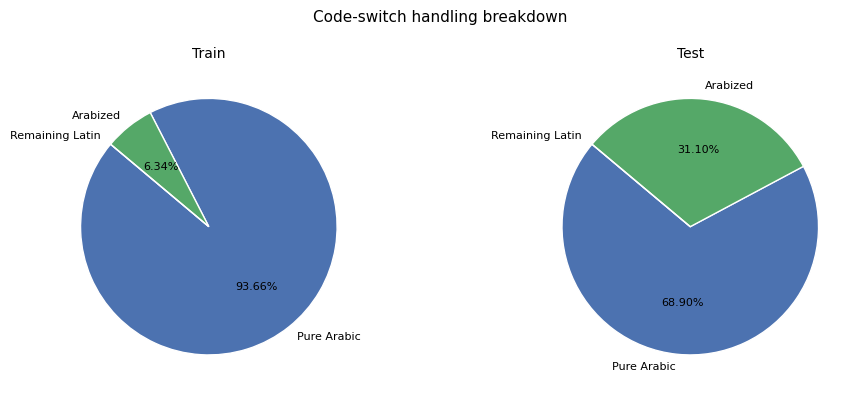

In [25]:
total_train  = len(df_train)
has_latin_tr = df_train["transcript_clean"].str.contains(r"[A-Za-z]", regex=True).sum()
remaining_tr = df_train["transcript_cs"].str.contains(r"[A-Za-z]", regex=True).sum()
total_test   = len(df_test)
has_latin_te = df_test["transcript_clean"].str.contains(r"[A-Za-z]", regex=True).sum()
remaining_te = df_test["transcript_cs"].str.contains(r"[A-Za-z]", regex=True).sum()

comparison_df = pd.DataFrame({
    "Metric":    ["Total segments", "With Latin (raw)", "Arabized (changed)", "Remaining Latin"],
    "Train":     [total_train, has_latin_tr, n_cs_train, remaining_tr],
    "Test":      [total_test,  has_latin_te, n_cs_test,  remaining_te],
})
comparison_df["Train (%)"] = [100, has_latin_tr/total_train*100,
                               n_cs_train/total_train*100, remaining_tr/total_train*100]
comparison_df["Test (%)"]  = [100, has_latin_te/total_test*100,
                               n_cs_test/total_test*100,  remaining_te/total_test*100]
print("\n========== Train vs Test Code-Switch Summary ==========")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ["Pure Arabic", "Arabized", "Remaining Latin"]
colors = ["#4C72B0", "#55A868", "#DD8452"]
for ax, (total, has_lat, changed, remain), title in [
    (axes[0], (total_train, has_latin_tr, n_cs_train, remaining_tr), "Train"),
    (axes[1], (total_test,  has_latin_te, n_cs_test,  remaining_te), "Test"),
]:
    values = [total - has_lat, changed, remain]
    ax.pie(values, labels=labels, colors=colors,
           autopct=lambda p: f"{p:.2f}%" if p > 2 else "", startangle=140,
           wedgeprops={"edgecolor": "white", "linewidth": 1}, textprops={"fontsize": 8})
    ax.set_title(title, fontsize=10)
fig.suptitle("Code-switch handling breakdown", fontsize=11)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/code_switch_train_test.png", bbox_inches="tight")
plt.show()


## 6 · NOTA Normalisation (`nota_normalizer.py`)

| Layer | Rule | Standard | Toggle |
|-------|------|----------|--------|
| 4 | word-final ى → ي (MSA exceptions preserved via lexicon) | CODA-TUN §5.2.1; NOTA §4 | `apply_alef_maqsura` |
| 5 | word-final ه → ة restoration (via taa_marbuta_ha_list.tsv) | COTA 2.0; NOTA §3 | `apply_taa_marbuta` |
| 6 | verb-final و → وا (Waw-of-Plurality, ≥3 chars, exclusion list) | CODA* §3; CODA-TUN §5.2.3 | `apply_waw_plurality` |
| 7 | word-initial أإآ → ا (glottal stop disappeared in TUN) | NOTA §2; CODA* simplified Hamza | `apply_hamza_drop` |
| 8 | ماقالش → ما قال ش (negation circumclitic separation) | CODA-TUN §5.2.3; COTA §4 | `apply_negation_split` |
| 9 | variant collapse (variant_collapse_map.tsv) | COTA 2.0 lexicon | `apply_variant_map` |
| 10 | hard canonical overrides (coda_word_list.tsv) | NOTA canonical list | `apply_overrides` |

> **Layer ordering note:** layers run highest-priority-first (10 → 4).  
> Layer 10 short-circuits all subsequent layers for the matched word.  
> All three normalisation methods (`normalize`, `normalize_with_flags`, `normalize_with_log`)  
> delegate to a single unified `_apply_word_layers` implementation — guaranteed consistent output.


In [27]:
normalizer = NOTANormalizer(
    lexicons_dir=LEXICONS_DIR,
    layer_flags=NOTA_LAYER_FLAGS,
)
print(f"NOTANormalizer — active layers: {[k for k,v in NOTA_LAYER_FLAGS.items() if v]}")
print(f"  gaf_exceptions        : {len(normalizer.gaf_exceptions):,}")
print(f"  variant_map           : {len(normalizer.variant_map):,}")
print(f"  canonical_overrides   : {len(normalizer.canonical_overrides):,}")
print(f"  taa_marbuta_ha        : {len(normalizer.taa_marbuta_ha):,}")
print(f"  alef_maqsura_preserve : {len(normalizer.alef_maqsura_preserve):,}")


NOTANormalizer — active layers: ['apply_hamza_drop', 'apply_negation_split', 'apply_variant_map', 'apply_overrides']
  gaf_exceptions        : 17
  variant_map           : 39
  canonical_overrides   : 13
  taa_marbuta_ha        : 435
  alef_maqsura_preserve : 712


In [28]:
# extract_words_from_pattern is now in src.utils (moved from nota_normalizer)
print(f"{'—' * 20}{'alef_maqsura':^15}{'—' * 20}")
extract_words_from_pattern(df_train['transcript_cs'], r"ى(?=\s|$)", N_EXAMPLES)
print(f"{'—' * 20}{'taa_marbuta':^15}{'—' * 20}")
extract_words_from_pattern(df_train['transcript_cs'], r"ه(?=\s|$)", N_EXAMPLES)
print(f"{'—' * 20}{'hamza_drop':^15}{'—' * 20}")
extract_words_from_pattern(df_train['transcript_cs'], r"(?<!\S)[أإ]", N_EXAMPLES)
print(f"{'—' * 20}{'negation_split':^15}{'—' * 20}")
extract_words_from_pattern(df_train['transcript_cs'], r"(ما)([^\s]{2,})(ش)(?=\s|$)", N_EXAMPLES)
print(f"{'—' * 20}{'waw_plurality':^15}{'—' * 20}")
extract_words_from_pattern(df_train['transcript_cs'], r"^(?=.{3,}$).*و$", N_EXAMPLES)


———————————————————— alef_maqsura  ————————————————————
Total unique words matching pattern: 712
Top words: على حتى الى اخرى جى تلقى الاولى يلقى مشى الاخرى
————————————————————  taa_marbuta  ————————————————————
Total unique words matching pattern: 8908
Top words: الله عليه انه فيه له عنده راه ايه حاجه آه
————————————————————  hamza_drop   ————————————————————
Total unique words matching pattern: 0
Top words: 
————————————————————negation_split ————————————————————
Total unique words matching pattern: 303
Top words: مانيش ماهوش ماهيش ماعادش ماهمش ماناش ماعرفش مانعرفش ماحبش ماكانش
———————————————————— waw_plurality ————————————————————
Total unique words matching pattern: 2610
Top words: وهو راهو انو نحكيو متاعو عندو شنو هاو الفريدو سورتو


In [29]:
# normalize_with_flags delegates to unified _apply_word_layers — consistent with normalize_with_log
df_train[['transcript_nota', 'flags']] = df_train['transcript_cs'].apply(
    lambda t: pd.Series(normalizer.normalize_with_flags(t)))
df_test[['transcript_nota', 'flags']]  = df_test['transcript_cs'].apply(
    lambda t: pd.Series(normalizer.normalize_with_flags(t)))

def expand_flags(df):
    flags_df = pd.json_normalize(df["flags"])
    # Remove existing flag columns to avoid duplication
    df = df.drop(columns=flags_df.columns, errors="ignore")
    return pd.concat([df, flags_df], axis=1).drop(columns=["flags"])
    
# Expand flags dict to separate boolean columns
df_train = expand_flags(df_train)
df_test  = expand_flags(df_test)

n_nota_train = (df_train["transcript_cs"] != df_train["transcript_nota"]).sum()
n_nota_test  = (df_test["transcript_cs"]  != df_test["transcript_nota"]).sum()
print(f"Segments modified by NOTA normalisation (train): {n_nota_train:6,} ({n_nota_train/len(df_train)*100:.2f}%)")
print(f"Segments modified by NOTA normalisation (test) : {n_nota_test:6,} ({n_nota_test/len(df_test)*100:.2f}%)")


Segments modified by NOTA normalisation (train):  6,450 (8.47%)
Segments modified by NOTA normalisation (test) :    117 (11.55%)


In [30]:
nota_changed = df_train["transcript_cs"] != df_train["transcript_nota"]
df_diff = df_train[nota_changed].head(N_EXAMPLES)
display(df_diff[["transcript_cs", "transcript_nota"]].style.set_properties(**{
    'text-align': 'right', 'direction': 'rtl', 'font-size': '12px'
}).hide())


transcript_cs,transcript_nota
اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو من بعد الا ما انا كانطريبرنور كباعث مشروع صارولي برشا مشاكل فالجستين و صارولي مشاكل مع لعباد لي كانت موفرتلي اللوجسيل ولا اللوجسيل اوف لنيه ولا لوجسيل بيراتي,اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو من بعد الا ما انا كانطروبرونور كباعث مشروع صارولي برشا مشاكل فالجستين و صارولي مشاكل مع لعباد لي كانت موفرتلي اللوجسيل ولا اللوجسيل اوف لنيه ولا لوجسيل بيراتي
ثمة غزوة كبيرة ياسر,فمة غزوة كبيرة ياسر
سلمان الفارسي هو من فارس موش من العرب,سلمان الفارسي هو من فارس مش من العرب
هذاكة آش بيه فارسي سلمان من فارس موش من العرب,هذاكة آش بيه فارسي سلمان من فارس مش من العرب
آه آه الحكاية ال الي طالعة توا النقاش الكبير الاستفتاء موش الاستفتاء انت ضد الاستفتاء,آه آه الحكاية ال الي طالعة توا النقاش الكبير الاستفتاء مش الاستفتاء انت ضد الاستفتاء
ثمة شكون يقول يلزم المجلس التاسيسي يجي باش ياسس,فمة شكون يقول يلزم المجلس التاسيسي يجي باش ياسس
معناتها لهنا الديفو في العقلية موش في ال ال,معناتها لهنا الديفو في العقلية مش في ال ال
تقول الي يحب فيسع المجلس تاسيسي يحب يشد رئيس زادا نفس الشي معناتها المجلس التاسيسي موش جاي يحب يحكم,تقول الي يحب فيسع المجلس تاسيسي يحب يشد رئيس زادة نفس الشي معناتها المجلس التاسيسي مش جاي يحب يحكم
يقول لك بعد الانتخابات في كل الحالات ثمة شكون موش مغشش,يقول لك بعد الانتخابات في كل الحالات فمة شكون مش مغشش
ثمة شكون يقول حتى ثمة احزاب,فمة شكون يقول حتى فمة احزاب


In [31]:
# normalize_with_log shares the same _apply_word_layers as normalize_with_flags
print("Detailed NOTA change log (first 3 modified segments):\n")
for text in df_train.loc[nota_changed, "transcript_cs"].head(3):
    _, changes = normalizer.normalize_with_log(str(text))
    if changes:
        print(f"  Input : {str(text)[:80]}")
        for c in changes:
            b = str(c.get("before",""))[:35]
            a = str(c.get("after",""))[:35]
            print(f"    L{c['layer']} [{c['rule']}]: {b!r} → {a!r}")
        print()


Detailed NOTA change log (first 3 modified segments):

  Input : اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو من بعد الا ما انا كانطريبرنور كبا
    L10 [canonical_override]: 'انا' → 'انا'
    L10 [canonical_override]: 'انا' → 'انا'
    L10 [canonical_override]: 'كانطريبرنور' → 'كانطروبرونور'
    L9 [variant_map]: 'برشا' → 'برشا'

  Input : ثمة غزوة كبيرة ياسر
    L9 [variant_map]: 'ثمة' → 'فمة'

  Input : سلمان الفارسي هو من فارس موش من العرب
    L10 [canonical_override]: 'هو' → 'هو'
    L9 [variant_map]: 'موش' → 'مش'



## 7 · Deep Analysis

### 7.1 Vocabulary reduction across all stages

In [33]:
stages = [
    ("raw",    df_train["transcript"].dropna().tolist()),
    ("clean",  df_train["transcript_clean"].dropna().tolist()),
    ("cs",     df_train["transcript_cs"].dropna().tolist()),
    ("nota",   df_train["transcript_nota"].dropna().tolist()),
]
print(f"  {'Stage':<8}  {'Char vocab':>12}  {'Word vocab':>12}  {'Δ chars':>10}  {'Δ words':>10}")
print("  " + "-"*60)
prev_c, prev_w = None, None
for name, texts in stages:
    cset, _ = get_char_vocab(texts)
    wctr    = get_word_vocab(texts)
    nc, nw  = len(cset), len(wctr)
    dc = f"-{prev_c-nc}" if prev_c else "—"
    dw = f"-{prev_w-nw}" if prev_w else "—"
    print(f"  {name:<8}  {nc:>12,}  {nw:>12,}  {dc:>10}  {dw:>10}")
    prev_c, prev_w = nc, nw


  Stage       Char vocab    Word vocab     Δ chars     Δ words
  ------------------------------------------------------------
  raw                127        69,133           —           —
  clean               82        67,637         -45       -1496
  cs                  35        66,008         -47       -1629
  nota                35        65,737          -0        -271


### 7.2 Character inventory (post-NOTA)

In [35]:
nota_texts = df_train["transcript_nota"].dropna().tolist()
nota_char_set, nota_char_counter = get_char_vocab(nota_texts)
nota_cats = categorize_vocab(nota_char_set)

print("Character inventory by category:")
for cat, chars in sorted(nota_cats.items()):
    print(f"  {cat:<22} ({len(chars):>3}): {' '.join(sorted(chars))}")


Character inventory by category:
  arabic_letter          ( 34): ء آ ؤ ئ ا ب ة ت ث ج ح خ د ذ ر ز س ش ص ض ط ظ ع غ ف ق ك ل م ن ه و ى ي
  whitespace             (  1):  


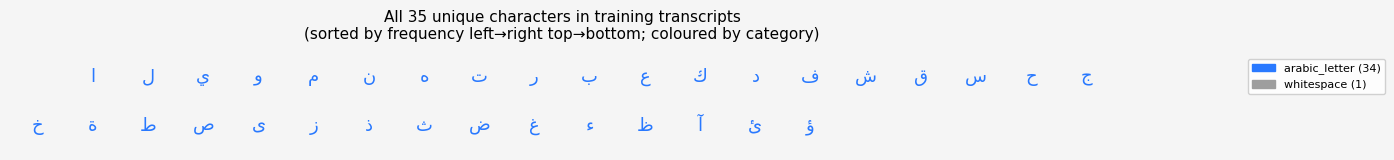

✓ Saved char_inventory.png → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\outputs\figures


In [36]:
all_chars_sorted = [c for c, _ in nota_char_counter.most_common()]
visualize_characters(all_chars_sorted, nota_cats, figures_path=FIGURES_PATH)
print(f"✓ Saved char_inventory.png → {FIGURES_PATH}")


### 7.3 Waw-of-Plurality analysis

In [38]:
waw_mask = df_train["waw_applied"].fillna(False).astype(bool)
waw_seg  = waw_mask.sum()

print(f"Waw-of-Plurality rule impact (train):")
print(f"  Rows affected           : {waw_seg:,}")
print(f"  Percentage affected     : {(waw_seg / len(df_train) * 100) if len(df_train) > 0 else 0:.2f}%")

if waw_seg > 0:
    df_diff = df_train[waw_mask & nota_changed].head(N_EXAMPLES)
    display(df_diff[["transcript_cs", "transcript_nota"]]
            .style.set_properties(**{'text-align': 'right', 'direction': 'rtl', 'font-size': '12px'}).hide())
else:
    print("No rows affected by Waw-of-Plurality rule.")


Waw-of-Plurality rule impact (train):
  Rows affected           : 0
  Percentage affected     : 0.00%
No rows affected by Waw-of-Plurality rule.


### 7.4 Negation circumclitic analysis

In [40]:
neg_mask = df_train["negation_applied"].fillna(False).astype(bool)
neg_rows = neg_mask.sum()
neg_pct  = (neg_rows / len(df_train) * 100) if len(df_train) > 0 else 0

print(f"Negation circumclitic separation impact (train):")
print(f"  Rows affected           : {neg_rows:,}")
print(f"  Percentage affected     : {neg_pct:.2f}%")
print()

if neg_rows > 0:
    df_diff = df_train[neg_mask].head(N_EXAMPLES)
    print("Examples of negation circumclitic separation:")
    display(df_diff[["transcript_cs", "transcript_nota"]]
            .style.set_properties(**{'text-align': 'right', 'direction': 'rtl', 'font-size': '12px'}).hide())
else:
    print("No rows affected by negation separation rule.")


Negation circumclitic separation impact (train):
  Rows affected           : 1,371
  Percentage affected     : 1.80%

Examples of negation circumclitic separation:


transcript_cs,transcript_nota
ماهواش باش يقول لك يقول لك ر رقد هاكي الامور خلي هاكي الامور غادي,ما هوا ش باش يقول لك يقول لك ر رقد هاكي الامور خلي هاكي الامور غادي
و في هالاثناء الماكينة الاقتصادية ماهياش قاعدة دور لانو ما ثمة حتى شخص باش يستثمر لك في البلاد,و في هالاثناء الماكينة الاقتصادية ما هيا ش قاعدة دور لانو ما فمة حتى شخص باش يستثمر لك في البلاد
بين قوسين راني مانيش معادي لرجال الاعمال انا نعتبر الي رجال الاعمال الشرفاء ونزهاء ما عندهم علاش يجيو يمدوا الفلوس لحزب سياسي,بين قوسين راني ما ني ش معادي لرجال الاعمال انا نعتبر الي رجال الاعمال الشرفاء ونزهاء ما عندهم علاش يجيو يمدوا الفلوس لحزب سياسي
خذاو امتيازات م م م ماهمش اهل لها,خذاو امتيازات م م م ما هم ش اهل لها
بربي متاع اراب آم هذاكة راهو ماهواش يضحك راهو راهو قديم قول لو بربي فيق على روحك راهو ما عادش تمشي بيها اللغة هذيكة في تونس بجاه ربي كان تعملوا مزية نحاوه,بربي متاع اراب آم هذاكة راهو ما هوا ش يضحك راهو راهو قديم قول لو بربي فيق على روحك راهو ما عادش تمشي بيها اللغة هذيكة في تونس بجاه ربي كان تعملوا مزية نحاوه
الناس الي تشدوا في بريود كاترز له كينز جانفيا و سيز جانفيا الناس المسلحة هذي ماناش باش نحكيو قناصة باش ما يقولش ما ثماش قناصة الناس الي تشدت وريناهم في الجزيرة,الناس الي تشدوا في بريود كاترز له كينز جانفيا و سيز جانفيا الناس المسلحة هاذي ما نا ش باش نحكيو قناصة باش ما يقولش ما ثماش قناصة الناس الي تشدت وريناهم في الجزيرة
يا اولادي راهي الدنيا الوسخ كلانا امشيو شوفوا انا نسكن في حي الزهور الاوساخ الي صايرة لنا في حي الزهور بلدية باردو مانيش فاهمة,يا اولادي راهي الدنيا الوسخ كلانا امشيو شوفوا انا نسكن في حي الزهور الاوساخ الي صايرة لنا في حي الزهور بلدية باردو ما ني ش فاهمة
ماهواش مستحيل الاقلاع عن التدخين,ما هوا ش مستحيل الاقلاع عن التدخين
شاك صواري نقول في ليل الي غدوة صباح نقوم مانيش متكيف سى فا كندسيون مقتنع لازم نحيه نعرفو يضر و,شاك صواري نقول في ليل الي غدوة صباح نقوم ما ني ش متكيف سى فا كندسيون مقتنع لازم نحيه نعرفو يضر و
حسينا زادا ثمة معاناة متاع الناس الي ماهيش عارفة وين تمشي,حسينا زادة فمة معاناة متاع الناس الي ما هي ش عارفة وين تمشي


### 7.5 Taa Marbuta / Ha confusion analysis

In [42]:
taa_mask = df_train["taa_applied"].fillna(False).astype(bool)
taa_rows = taa_mask.sum()
taa_pct  = (taa_rows / len(df_train) * 100) if len(df_train) > 0 else 0

print(f"Taa Marbuta restoration impact (train):")
print(f"  Rows affected           : {taa_rows:,}")
print(f"  Percentage affected     : {taa_pct:.2f}%")
print()
print(f"Taa Marbuta restorations via table: {len(normalizer.taa_marbuta_ha):,} entries in lexicon")
print()
print("ℹ Taa Marbuta restoration requires manual lexicon expansion.")
print("  Inspect the most frequent word-final-ه forms and add to taa_marbuta_ha_list.tsv:")

all_words = [w for t in df_train["transcript_clean"].dropna() for w in t.split()]
ha_words  = [w for w in all_words if w.endswith("ه")]
top_ha    = Counter(ha_words).most_common(5)

print()
print(f"  {'Count':>6}  Word  (check if ة is correct)")
for w, cnt in top_ha:
    print(f"  {cnt:>6}  {w}")


Taa Marbuta restoration impact (train):
  Rows affected           : 0
  Percentage affected     : 0.00%

Taa Marbuta restorations via table: 435 entries in lexicon

ℹ Taa Marbuta restoration requires manual lexicon expansion.
  Inspect the most frequent word-final-ه forms and add to taa_marbuta_ha_list.tsv:

   Count  Word  (check if ة is correct)
    2003  الله
    1467  عليه
    1265  انه
    1148  فيه
     896  له


### 7.6 Alef Maqsura / Ya confusion analysis

In [44]:
ya_mask = df_train["alef_applied"].fillna(False).astype(bool)
ya_rows = ya_mask.sum()
ya_pct  = (ya_rows / len(df_train) * 100) if len(df_train) > 0 else 0

print(f"Alif Maqsura (ى → ي) restoration impact (train):")
print(f"  Rows affected           : {ya_rows:,}")
print(f"  Percentage affected     : {ya_pct:.2f}%")
print(f"Yaa restorations via table: {len(normalizer.alef_maqsura_preserve):,} entries in lexicon")
print()
print("ℹ Yaa restoration requires manual lexicon expansion.")
print("  Inspect the most frequent word-final-ى forms and add to alef_maqsura_list.tsv:")
all_words = [w for t in df_train["transcript_clean"].dropna() for w in t.split()]
ya_words  = [w for w in all_words if w.endswith("ى")]
top_ya    = Counter(ya_words).most_common(5)
print()
print(f"  {'Count':>6}  Word  (check if ة is correct)")
for w, cnt in top_ya:
    print(f"  {cnt:>6}  {w}")


Alif Maqsura (ى → ي) restoration impact (train):
  Rows affected           : 0
  Percentage affected     : 0.00%
Yaa restorations via table: 712 entries in lexicon

ℹ Yaa restoration requires manual lexicon expansion.
  Inspect the most frequent word-final-ى forms and add to alef_maqsura_list.tsv:

   Count  Word  (check if ة is correct)
    7621  على
    2795  حتى
     482  الى
     470  اخرى
     455  جى


### 7.7 Remaining Latin characters — policy decision

In [46]:
_LATIN_RE      = re.compile(r"[A-Za-z]")
nota_texts_all = df_train["transcript_nota"].dropna().tolist()
remaining_latin_words = [w for t in nota_texts_all for w in t.split() if _LATIN_RE.search(w)]
remaining_nota_set, _ = get_char_vocab(nota_texts_all)
remaining_latin_chars = [c for c in remaining_nota_set if classify_char(c) == "latin_letter"]

print(f"Latin characters still present: {sorted(remaining_latin_chars)}")
print(f"Latin-containing word tokens  : {len(remaining_latin_words):,}")
print()
top_rem = Counter(remaining_latin_words).most_common(40)
if top_rem:
    print("Top 40 remaining Latin words — consider adding to loanword_arabization.tsv:")
    for word, cnt in top_rem:
        print(f"  ({cnt:>5}) {word}")
else:
    print('✓ none remain')


Latin characters still present: []
Latin-containing word tokens  : 0

✓ none remain


### 7.8 Word-frequency distribution

Unique words      : 65,737
Hapax (freq=1)    : 35,374  (53.8%)
Low-freq (freq<5) : 52,799  (80.3%)


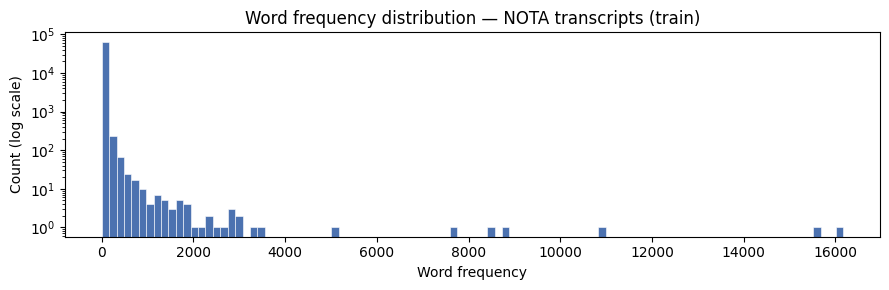

In [48]:
wc = get_word_vocab(nota_texts_all)
total_u  = len(wc)
hapax    = sum(1 for c in wc.values() if c == 1)
low_freq = sum(1 for c in wc.values() if c < 5)

print(f"Unique words      : {total_u:,}")
print(f"Hapax (freq=1)    : {hapax:,}  ({hapax/total_u*100:.1f}%)")
print(f"Low-freq (freq<5) : {low_freq:,}  ({low_freq/total_u*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(list(wc.values()), bins=100, log=True,
        color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Word frequency")
ax.set_ylabel("Count (log scale)")
ax.set_title("Word frequency distribution — NOTA transcripts (train)")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/word_freq_distribution.png", bbox_inches="tight")
plt.show()


### 7.9 Text-length summary across all pipeline stages

In [50]:
def _len_stats(series, label):
    lens = series.str.len()
    return {"stage": label, "mean": round(lens.mean(),1), "median": round(lens.median(),1),
            "std": round(lens.std(),1), "min": int(lens.min()),
            "max": int(lens.max()), "empty": int((lens==0).sum())}

stats = pd.DataFrame([
    _len_stats(df_train["transcript"],       "raw"),
    _len_stats(df_train["transcript_clean"], "clean"),
    _len_stats(df_train["transcript_cs"],    "cs"),
    _len_stats(df_train["transcript_nota"],  "nota"),
])
print(stats.to_string(index=False))


stage  mean  median  std  min  max  empty
  raw  36.8    36.0 30.6    1  605      0
clean  36.8    36.0 30.5    1  605      0
   cs  36.6    36.0 30.1    1  605      0
 nota  36.7    36.0 30.2    1  607      0


## 8 · Quality Gate

Drop segments whose final NOTA transcript is shorter than `min_transcript_length`.
Every dropped row is logged to per-split JSONL files (`dropped_train.jsonl`,
`dropped_test.jsonl`) — consistent with `run_text_pipeline.py` behaviour.


In [52]:
def apply_quality_gate(df, min_len):
    mask = df["transcript_nota"].str.strip().str.len() >= min_len
    return df[mask].copy(), df[~mask].copy()

df_train_clean, df_train_dropped = apply_quality_gate(df_train, MIN_TRANSCRIPT_LEN)
df_test_clean,  df_test_dropped  = apply_quality_gate(df_test,  MIN_TRANSCRIPT_LEN)

print(f"Train  kept   : {len(df_train_clean):,}  ({len(df_train_clean)/len(df_train)*100:.2f}%)")
print(f"Train  dropped: {len(df_train_dropped):,}  ({len(df_train_dropped)/len(df_train)*100:.2f}%)")
print(f"Test   kept   : {len(df_test_clean):,}  ({len(df_test_clean)/len(df_test)*100:.2f}%)")
print(f"Test   dropped: {len(df_test_dropped):,}  ({len(df_test_dropped)/len(df_test)*100:.2f}%)")


Train  kept   : 76,080  (99.95%)
Train  dropped: 35  (0.05%)
Test   kept   : 1,013  (100.00%)
Test   dropped: 0  (0.00%)


In [53]:
# Per-split drop logs in append mode — consistent with run_text_pipeline.py
for split_name, dropped in [("train", df_train_dropped), ("test", df_test_dropped)]:
    log_path = f"{TEXT_OUT_PATH}/dropped_{split_name}.jsonl"
    with open(log_path, "a", encoding="utf-8") as fh:
        for _, row in dropped.iterrows():
            fh.write(json.dumps({
                "split":           split_name,
                "audio_id":        row["audio_id"],
                "phase":           3,
                "reason":          "transcript_too_short",
                "transcript_nota": str(row["transcript_nota"]),
                "char_len":        len(str(row["transcript_nota"]).strip()),
            }, ensure_ascii=False) + "\n")
    print(f"✓ Drop log ({split_name}): {len(dropped):,} rows → {log_path}")

print(f"\nTotal dropped: {len(df_train_dropped) + len(df_test_dropped):,} rows")


✓ Drop log (train): 35 rows → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\text_clean/dropped_train.jsonl
✓ Drop log (test): 0 rows → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\text_clean/dropped_test.jsonl

Total dropped: 35 rows


## 9 · Save Outputs

Column lineage:

| Column | Content | Status |
|--------|---------|--------|
| `transcript` | Original annotation | read-only reference |
| `transcript_raw` | Original raw | provenance only |
| `transcript_clean` | After cleaning (diacritics, unicode, punct, corrections) | intermediate |
| `transcript_cs` | After code-switch Arabization | intermediate |
| `transcript_nota` | After full NOTA normalisation | **ASR training target** |


In [55]:
train_out = f"{TEXT_OUT_PATH}/df_train_clean.parquet"
test_out  = f"{TEXT_OUT_PATH}/df_test_clean.parquet"

df_train_clean.to_parquet(train_out, index=False)
df_test_clean.to_parquet(test_out,   index=False)

print(f"✓ df_train_clean → {train_out}")
print(f"  {len(df_train_clean):,} rows × {df_train_clean.shape[1]} cols")
print(f"\n✓ df_test_clean  → {test_out}")
print(f"  {len(df_test_clean):,} rows × {df_test_clean.shape[1]} cols")


✓ df_train_clean → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\text_clean/df_train_clean.parquet
  76,080 rows × 21 cols

✓ df_test_clean  → C:\Users\MSI\Desktop\ASR\asr_tn_pielines\data\interim\text_clean/df_test_clean.parquet
  1,013 rows × 21 cols


## 10 · Summary

In [57]:
raw_chars, _  = get_char_vocab(df_train["transcript"].dropna().tolist())
nota_chars, _ = get_char_vocab(df_train_clean["transcript_nota"].dropna().tolist())

print_section("TEXT PREPROCESSING — PHASE 3 SUMMARY")
print_dict({
    "Standards applied         ": "NOTA 2024 (CODA-TUN→COTA→CODA*→NOTA)",
    "Train segments  in        ": f"{len(df_train):,}",
    "Train segments  out       ": f"{len(df_train_clean):,}",
    "Train segments  dropped   ": f"{len(df_train_dropped):,} ({len(df_train_dropped)/len(df_train)*100:.2f}%)",
    "Test  segments  in        ": f"{len(df_test):,}",
    "Test  segments  out       ": f"{len(df_test_clean):,}",
    "Char vocab  raw           ": f"{len(raw_chars):,}",
    "Char vocab  post-NOTA     ": f"{len(nota_chars):,}",
    "Vocab reduction           ": f"{len(raw_chars)-len(nota_chars):,} chars removed",
    "Modified by cleaning      ": f"{(df_train['transcript']!=df_train['transcript_clean']).sum():,}",
    "Modified by code-switch   ": f"{n_cs_train:,}",
    "Modified by NOTA          ": f"{n_nota_train:,}",
    "Transcript corrections    ": f"{len(corrections)} rules applied",
    "Code-switch policy        ": CS_POLICY,
    "Digits kept               ": str(KEEP_DIGITS),
    "Waw-of-Plurality          ": f"applied to {waw_seg:,} segments" if NOTA_LAYER_FLAGS.get("apply_waw_plurality") else "disabled",
    "Negation separations      ": f"{neg_rows:,} segments affected",
}, title="Phase 3 — text preprocessing")

print("\nFinal columns saved:")
for col in df_train_clean.columns:
    marker = " ← training target" if col == "transcript_nota" else ""
    print(f"  {col}{marker}")



════════════════════════════════════════════════════════════
  TEXT PREPROCESSING — PHASE 3 SUMMARY
════════════════════════════════════════════════════════════

──────────────────────────────────────────────────
  Phase 3 — text preprocessing
──────────────────────────────────────────────────
  Standards applied                   NOTA 2024 (CODA-TUN→COTA→CODA*→NOTA)
  Train segments  in                  76,115
  Train segments  out                 76,080
  Train segments  dropped             35 (0.05%)
  Test  segments  in                  1,013
  Test  segments  out                 1,013
  Char vocab  raw                     127
  Char vocab  post-NOTA               35
  Vocab reduction                     92 chars removed
  Modified by cleaning                18,062
  Modified by code-switch             4,822
  Modified by NOTA                    6,450
  Transcript corrections              12 rules applied
  Code-switch policy                  arabize
  Digits kept                 

In [58]:
df_train_clean[[
    "audio_id", "seg_start", "seg_end",
    "transcript", "transcript_clean", "transcript_cs", "transcript_nota"
]].head(6)


,audio_id,seg_start,seg_end,transcript,transcript_clean,transcript_cs,transcript_nota
0,amenyKH_0000001_0000020_1_20_0,0.0,14.113000,أسبقية قبل أنا ما وصلت خممت فيه كيما باش نحكيو...,اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو...,اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو...,اسبقية قبل انا ما وصلت خممت فيه كيما باش نحكيو...
1,amenyKH_0000001_chunk_0000001_001_chunk_1_0,0.0,3.496625,و الصلاة و السلام على رسول الله,و الصلاة و السلام على رسول الله,و الصلاة و السلام على رسول الله,و الصلاة و السلام على رسول الله
2,amenyKH_0000001_chunk_0000002_001_chunk_2_0,0.0,4.328063,و على آله وصحابته و من والاه,و على آله وصحابته و من والاه,و على آله وصحابته و من والاه,و على آله وصحابته و من والاه
3,amenyKH_0000001_chunk_0000003_001_chunk_3_0,0.0,4.297500,ربنا لا تزغ قلوبنا بعد إذ هديتنا,ربنا لا تزغ قلوبنا بعد اذ هديتنا,ربنا لا تزغ قلوبنا بعد اذ هديتنا,ربنا لا تزغ قلوبنا بعد اذ هديتنا
4,amenyKH_0000001_chunk_0000004_001_chunk_4_0,0.0,3.285187,وهب لنا من لدنك رحمة,وهب لنا من لدنك رحمة,وهب لنا من لدنك رحمة,وهب لنا من لدنك رحمة
5,amenyKH_0000001_chunk_0000005_001_chunk_5_0,0.0,3.241688,إنك أنت الوهاب,انك انت الوهاب,انك انت الوهاب,انك انت الوهاب
